# 02 Train Set EDA

Stage 5 explores only training participants and valid training epochs. The goal is to understand class balance, participant variability, signal summaries, representative raw epochs, and label transitions without using validation or test data for preprocessing or modeling decisions.

This notebook expects the Stage 3 split at `data/interim/split_assignments.csv`. It loads the Stage 4 epoch index from `data/interim/epoch_index.csv` when available, or builds it from raw DREAMT CSVs under `data/raw/` when it is missing. Raw CSVs are also needed for raw signal summaries and representative epoch plots.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
try:
    from IPython.display import Markdown, display
except ModuleNotFoundError:
    class Markdown(str):
        pass

    def display(value):
        print(value)

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.data import (
    DEFAULT_EPOCH_INDEX_PATH,
    DEFAULT_RAW_DATA_DIR,
    DEFAULT_SPLIT_ASSIGNMENTS_PATH,
    EXPECTED_SIGNAL_COLUMNS,
    build_epoch_index,
    load_participant_csv,
    load_split_assignments,
)
from src.plots import (
    ACC_MAG_COLUMN,
    add_acc_magnitude,
    collect_epoch_signal_summaries,
    plot_class_balance,
    plot_hypnogram,
    plot_participant_class_distribution,
    plot_raw_epoch_channels,
    plot_signal_summary_by_stage,
    plot_transition_matrix,
    select_representative_epochs,
    summarize_class_balance,
    summarize_participant_class_distribution,
    transition_matrices,
    valid_training_epochs,
)
from src.preprocessing import TARGET_SLEEP_STAGE_LABELS, summarize_epoch_index

try:
    import seaborn as sns

    sns.set_theme(style="whitegrid", context="notebook")
except ModuleNotFoundError:
    plt.style.use("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

raw_data_dir = repo_root / DEFAULT_RAW_DATA_DIR
epoch_index_path = repo_root / DEFAULT_EPOCH_INDEX_PATH
split_assignments_path = repo_root / DEFAULT_SPLIT_ASSIGNMENTS_PATH
figures_dir = repo_root / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
MAX_SIGNAL_SUMMARY_EPOCHS_PER_STAGE = 750


## Load Training Epochs

The split assignment file defines which participants are in training. If the Stage 4 epoch index is missing, this notebook builds it from the local raw DREAMT CSVs before filtering to `split == "train"` for predictive EDA. The cell also summarizes the full epoch index and checks that no non-training participants leak into the training-only EDA. Validation and test rows are left unused.

In [2]:
split_df = load_split_assignments(split_assignments_path)
train_participants = set(split_df.loc[split_df["split"] == "train", "participant_id"])

if epoch_index_path.exists():
    epoch_index = pd.read_csv(epoch_index_path, dtype={"participant_id": str})
    print(
        f"Loaded existing Stage 4 epoch index from {epoch_index_path}."
    )
else:
    print(
        f"Missing {epoch_index_path}. Building Stage 4 epoch index from "
        f"{raw_data_dir}."
    )
    epoch_index = build_epoch_index(
        raw_dir=raw_data_dir,
        split_assignments_path=split_assignments_path,
        output_path=epoch_index_path,
    )

epoch_index_summary = summarize_epoch_index(epoch_index)
valid_train_epochs = valid_training_epochs(epoch_index)
leaked_participants = set(valid_train_epochs["participant_id"]) - train_participants
if leaked_participants:
    raise ValueError(
        "Training EDA contains participant(s) not assigned to train: "
        f"{sorted(leaked_participants)}"
    )
print(
    f"Using {len(epoch_index):,} indexed epochs; "
    f"{len(valid_train_epochs):,} valid training epochs from "
    f"{valid_train_epochs['participant_id'].nunique():,} participants."
)
display(epoch_index_summary)

split_df["split"].value_counts().rename_axis("split").reset_index(name="participants")


Loaded existing Stage 4 epoch index from /home/manns79/dreamt-wearable-sleep-staging/data/interim/epoch_index.csv.
Using 106,060 indexed epochs; 55,793 valid training epochs from 70 participants.


{'total_participants_processed': 100,
 'total_epochs': 106060,
 'valid_epochs': 80089,
 'excluded_epochs': 25971,
 'exclusion_counts': {'missing_or_invalid_label': 25770,
  'label_changed_within_epoch': 101,
  'unexpected_row_count': 100},
 'valid_epoch_counts_by_split': {'train': 55793,
  'test': 12269,
  'validation': 12027},
 'valid_epoch_counts_by_mapped_label': {'Non-REM': 51561,
  'Wake': 20125,
  'REM': 8403},
 'valid_epoch_counts_by_participant': {'S002': 743,
  'S003': 829,
  'S004': 836,
  'S005': 733,
  'S006': 843,
  'S007': 821,
  'S008': 748,
  'S009': 807,
  'S010': 824,
  'S011': 814,
  'S012': 855,
  'S013': 786,
  'S014': 796,
  'S015': 955,
  'S016': 836,
  'S017': 828,
  'S018': 821,
  'S019': 720,
  'S020': 840,
  'S021': 796,
  'S022': 862,
  'S023': 842,
  'S024': 819,
  'S025': 826,
  'S026': 760,
  'S027': 806,
  'S028': 799,
  'S029': 805,
  'S030': 843,
  'S031': 844,
  'S032': 810,
  'S033': 798,
  'S034': 716,
  'S035': 711,
  'S036': 941,
  'S037': 795,
  

,split,participants
0,train,70
1,validation,15
2,test,15


## Class Balance

Class imbalance in the training set informs both modeling and evaluation. This section counts valid training epochs by mapped label, plots the class proportions, and prints a short interpretation. If one class is rare, accuracy can look good while minority-class recall is poor, so later model reports should emphasize macro F1, per-class precision, recall, F1, and confusion matrices.

,mapped_label,n_epochs,percentage
0,Wake,15196,27.236392
1,Non-REM,34933,62.611797
2,REM,5664,10.151811


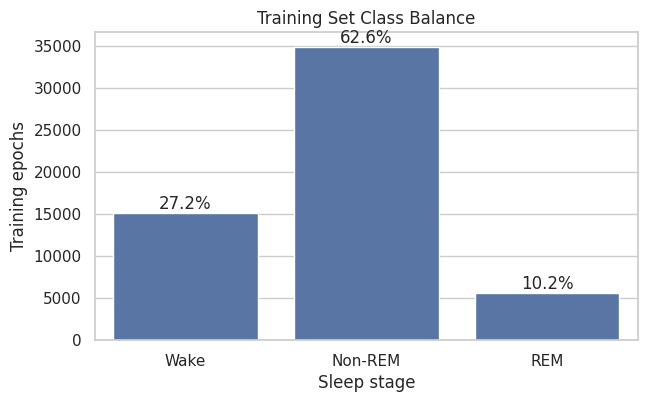

**Interpretation.** The least represented training class is `REM` (10.2%), while `Non-REM` is most represented (62.6%). This supports reporting macro F1 and per-class precision/recall/F1 rather than accuracy alone.

In [3]:
if valid_train_epochs.empty:
    class_balance = pd.DataFrame(columns=["mapped_label", "n_epochs", "percentage"])
    print("No valid training epochs are available yet.")
else:
    class_balance = summarize_class_balance(valid_train_epochs)
    display(class_balance)
    plot_class_balance(
        class_balance,
        save_path=figures_dir / "stage5_train_class_balance.png",
    )
    plt.show()

if not class_balance.empty:
    minority = class_balance.sort_values("percentage").iloc[0]
    majority = class_balance.sort_values("percentage").iloc[-1]
    display(
        Markdown(
            f"**Interpretation.** The least represented training class is "
            f"`{minority['mapped_label']}` ({minority['percentage']:.1f}%), "
            f"while `{majority['mapped_label']}` is most represented "
            f"({majority['percentage']:.1f}%). This supports reporting "
            "macro F1 and per-class precision/recall/F1 rather than accuracy alone."
        )
    )


## Participant-Level Class Distributions

Participant-level percentages show whether class balance is driven by a few participants or is broadly shared. The outputs show the smallest and largest participant epoch counts, a participant-by-class distribution plot, and a count of participants with zero epochs for each class. Large heterogeneity would support participant-aware evaluation, class weighting, and caution when interpreting aggregate metrics.

,participant_id,total_epochs,Wake_count,Non-REM_count,REM_count,Wake_percentage,Non-REM_percentage,REM_percentage
24,S035,711,64,538,109,9.001406,75.668073,15.330520
23,S034,716,96,586,34,13.407821,81.843575,4.748603
57,S087,719,610,109,0,84.840056,15.159944,0.000000
11,S019,720,293,382,45,40.694444,53.055556,6.250000
30,S046,722,174,466,82,24.099723,64.542936,11.357341
50,S077,724,11,573,140,1.519337,79.143646,19.337017
52,S080,726,174,446,106,23.966942,61.432507,14.600551
40,S063,728,191,498,39,26.236264,68.406593,5.357143
48,S075,728,202,460,66,27.747253,63.186813,9.065934
53,S082,730,619,111,0,84.794521,15.205479,0.000000


,participant_id,total_epochs,Wake_count,Non-REM_count,REM_count,Wake_percentage,Non-REM_percentage,REM_percentage
4,S006,843,252,591,0,29.893238,70.106762,0.000000
21,S031,844,31,748,65,3.672986,88.625592,7.701422
25,S039,844,82,663,99,9.715640,78.554502,11.729858
42,S065,844,352,396,96,41.706161,46.919431,11.374408
39,S061,850,123,622,105,14.470588,73.176471,12.352941
47,S074,851,5,707,139,0.587544,83.078731,16.333725
8,S012,855,172,559,124,20.116959,65.380117,14.502924
13,S022,862,303,476,83,35.150812,55.220418,9.628770
67,S100,862,45,684,133,5.220418,79.350348,15.429234
28,S043,900,223,562,115,24.777778,62.444444,12.777778


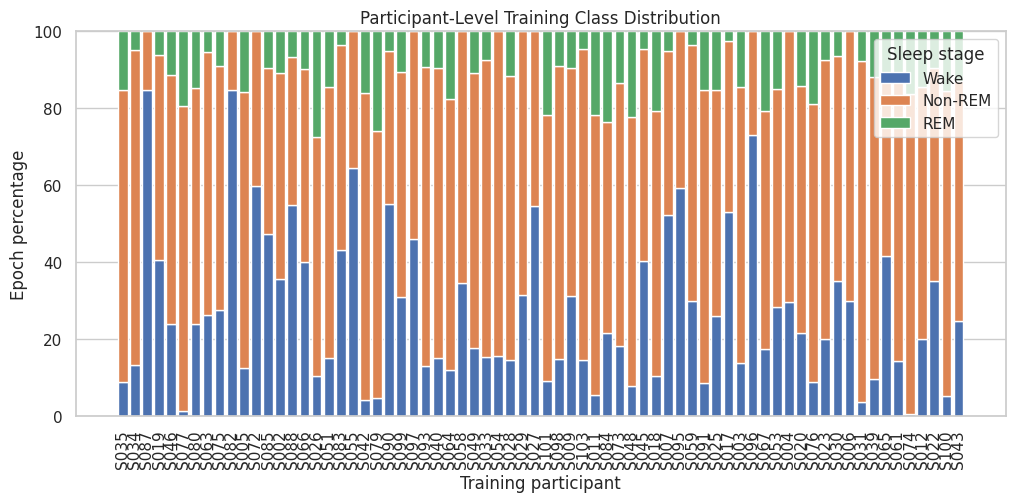

**Interpretation.** Training participants with zero epochs by class: `Wake` = 0, `Non-REM` = 0, `REM` = 13. Participants with missing classes can make per-participant behavior uneven, so participant-level splits remain important.

In [4]:
if valid_train_epochs.empty:
    participant_class_distribution = pd.DataFrame()
    print("No valid training epochs are available yet.")
else:
    participant_class_distribution = summarize_participant_class_distribution(
        valid_train_epochs
    )
    display(participant_class_distribution.sort_values("total_epochs").head(10))
    display(participant_class_distribution.sort_values("total_epochs").tail(10))
    plot_participant_class_distribution(
        participant_class_distribution,
        save_path=figures_dir / "stage5_train_participant_class_distribution.png",
    )
    plt.show()

    zero_class_counts = {
        label: int((participant_class_distribution[f"{label}_count"] == 0).sum())
        for label in TARGET_SLEEP_STAGE_LABELS
    }
    display(
        Markdown(
            "**Interpretation.** Training participants with zero epochs by class: "
            + ", ".join(f"`{label}` = {count}" for label, count in zero_class_counts.items())
            + ". Participants with missing classes can make per-participant behavior uneven, "
            "so participant-level splits remain important."
        )
    )


## Signal Distributions By Sleep Stage

The next analysis uses raw training CSVs to compute simple epoch-level summaries. The first cell samples valid training epochs and processes participant files one at a time; the second reshapes those summaries for descriptive tables and plots. The cap below keeps exploratory plotting responsive; increase it locally if you want full-training summary plots.

In [5]:
if valid_train_epochs.empty:
    epoch_signal_summaries = pd.DataFrame()
    print("No valid training epochs are available yet.")
elif not raw_data_dir.exists():
    epoch_signal_summaries = pd.DataFrame()
    print(f"Missing raw data directory: {raw_data_dir}")
else:
    try:
        epoch_signal_summaries = collect_epoch_signal_summaries(
            valid_train_epochs,
            raw_data_dir=raw_data_dir,
            max_epochs_per_stage=MAX_SIGNAL_SUMMARY_EPOCHS_PER_STAGE,
            random_state=RANDOM_STATE,
        )
        print(f"Computed signal summaries for {len(epoch_signal_summaries):,} epochs.")
    except FileNotFoundError as exc:
        epoch_signal_summaries = pd.DataFrame()
        print(exc)

epoch_signal_summaries.head()


Computed signal summaries for 2,250 epochs.


,participant_id,epoch_id,mapped_label,BVP_mean,BVP_std,BVP_median,BVP_iqr,ACC_X_mean,ACC_X_std,ACC_X_median,ACC_X_iqr,ACC_Y_mean,ACC_Y_std,ACC_Y_median,ACC_Y_iqr,ACC_Z_mean,ACC_Z_std,ACC_Z_median,ACC_Z_iqr,TEMP_mean,TEMP_std,TEMP_median,TEMP_iqr,EDA_mean,EDA_std,EDA_median,EDA_iqr,HR_mean,HR_std,HR_median,HR_iqr,IBI_mean,IBI_std,IBI_median,IBI_iqr,ACC_MAG_mean,ACC_MAG_std,ACC_MAG_median,ACC_MAG_iqr
0,S002,393,Wake,-0.126568,9.654016,0.270,10.5100,-20.658333,0.729011,-21.0,1.0,-25.001042,0.161413,-25.0,0.0,55.923958,0.495366,56.0,0.0,32.406667,0.016402,32.41,0.02,0.076143,0.001004,0.075567,0.001280,66.351667,0.589787,66.360,0.95,0.952401,0.058783,0.937500,0.015625,64.652694,0.373627,64.822835,0.317022
1,S002,1025,Wake,0.050224,48.475541,0.175,10.3425,-33.737500,3.913320,-33.0,1.0,-23.107292,3.611393,-21.0,2.0,49.792708,3.668912,51.0,2.0,35.142333,0.018746,35.15,0.02,0.137685,0.001384,0.137045,0.001280,77.772000,2.235987,77.975,3.38,1.046875,0.000000,1.046875,0.000000,64.737818,1.513663,64.606501,0.796338
2,S002,774,Wake,0.171802,38.374223,1.675,16.8375,-27.552083,4.969883,-28.0,1.0,-10.877083,2.510529,-11.0,1.0,56.867708,4.420121,57.0,0.0,35.013333,0.016402,35.00,0.03,0.158210,0.001470,0.158818,0.001281,63.322333,0.727365,63.275,0.55,0.987419,0.043689,1.000000,0.046875,64.467042,2.425227,64.451532,0.428099
3,S002,772,Wake,-0.225682,10.932177,-0.240,15.0275,-25.715625,0.511836,-26.0,1.0,-26.959375,0.291294,-27.0,0.0,52.923958,0.405086,53.0,0.0,35.079333,0.016115,35.07,0.02,0.158679,0.000933,0.158818,0.001281,62.544333,0.622629,62.400,1.02,0.975448,0.114554,1.000000,0.234375,64.725856,0.347672,64.915329,0.394015
4,S002,803,Wake,-2.730724,287.698923,-0.725,184.6175,12.626042,8.695338,11.0,1.0,-45.657292,3.764601,-47.0,1.0,43.018750,3.909831,43.0,1.0,34.138333,0.013686,34.14,0.02,0.161935,0.006574,0.160099,0.002562,68.522000,5.988598,67.525,10.83,0.984375,0.000000,0.984375,0.000000,64.728300,3.143819,64.645185,0.541551


count       mean        std        min        25%  \
signal  mapped_label                                                      
ACC_MAG Non-REM       750.0  64.163972   1.096633  61.362337  63.443803   
        REM           750.0  64.341546   0.973005  61.248407  63.870629   
        Wake          750.0  64.283631   1.227813  61.161020  63.505987   
BVP     Non-REM       750.0  -0.003728   0.599790  -6.494844  -0.162879   
        REM           750.0  -0.018088   0.658408  -6.238219  -0.174521   
        Wake          750.0  -0.036970   1.087603  -5.014594  -0.296081   
EDA     Non-REM       750.0   1.613091   3.595163   0.000000   0.178348   
        REM           750.0   1.196944   1.729418   0.000000   0.204324   
        Wake          750.0   0.972119   1.704117   0.000000   0.121465   
HR      Non-REM       750.0  66.693886  12.664815  43.494333  58.313000   
        REM           750.0  66.342884  11.163975  40.423000  58.785667   
        Wake          750.0  70.319796  12.634276  43.707333  61.019333   
IBI     Non-REM       750.0   0.933352   0.181334   0.390625   0.806256   
        REM           750.0   0.914407   0.166574   0.390625   0.798002   
        Wake          750.0   0.905570   0.189715   0.359375   0.765625   
TEMP    Non-REM       750.0  34.036143   2.239590  20.079000  33.290333   
        REM           750.0  33.792857   2.275547  21.964000  32.998083   
        Wake          750.0  33.667932   2.195250  21.949333  32.663250   

                            50%        75%         max  
signal  mapped_label                                    
ACC_MAG Non-REM       64.303054  64.931043   67.249783  
        REM           64.497530  64.975576   66.721021  
        Wake          64.454907  65.045887   68.276388  
BVP     Non-REM       -0.000742   0.167483    6.628266  
        REM            0.001055   0.160887    4.293958  
        Wake          -0.003435   0.247977    6.244005  
EDA     Non-REM        0.432015   1.256459   52.515424  
        REM            0.467451   1.310152   13.035814  
        Wake           0.272730   0.690772   13.064946  
HR      Non-REM       65.526000  73.948750  162.856000  
        REM           65.444833  72.760167  113.475000  
        Wake          69.424833  78.123250  132.950000  
IBI     Non-REM        0.914823   1.031250    1.481006  
        REM            0.893005   1.016518    1.515625  
        Wake           0.890625   1.036383    1.433146  
TEMP    Non-REM       34.531000  35.503583   37.341000  
        REM           34.325167  35.245833   36.610667  
        Wake          34.118000  35.160333   37.298000

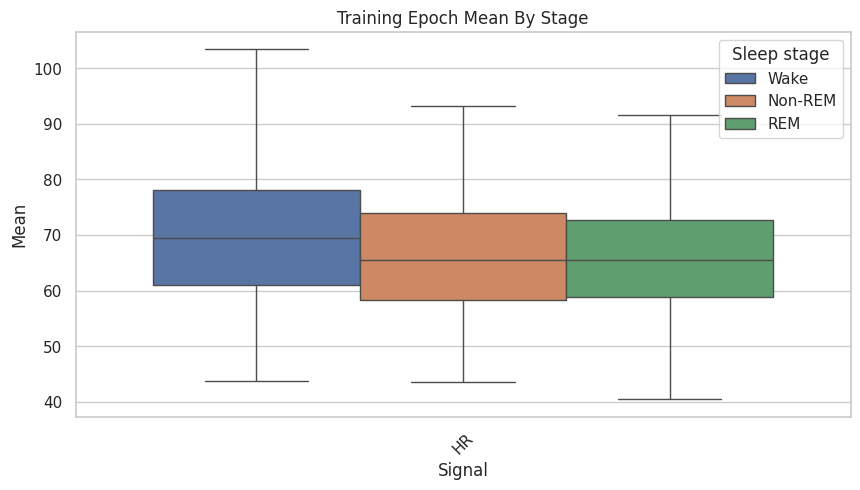

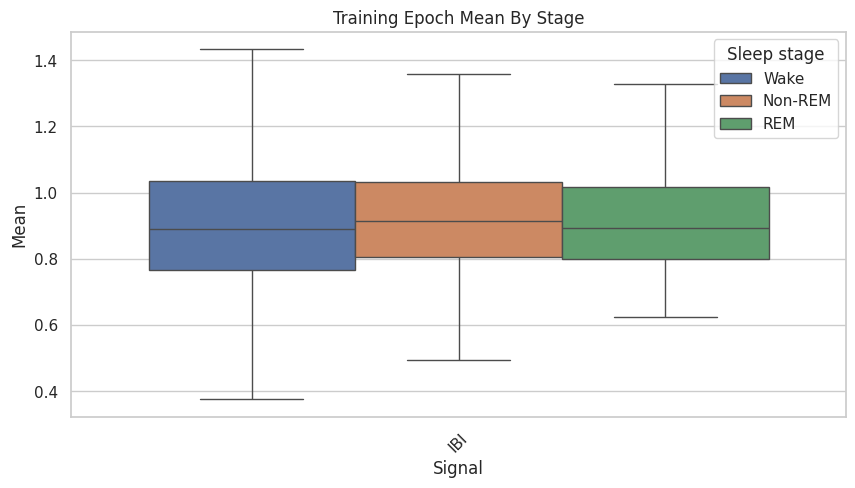

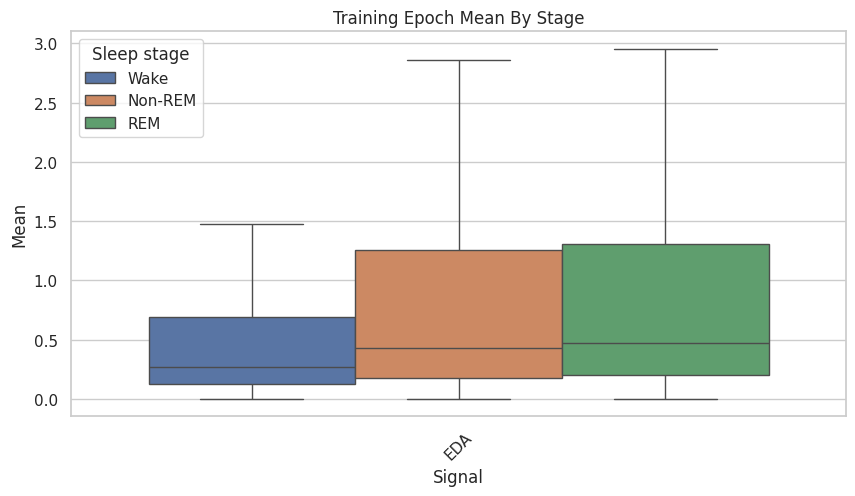

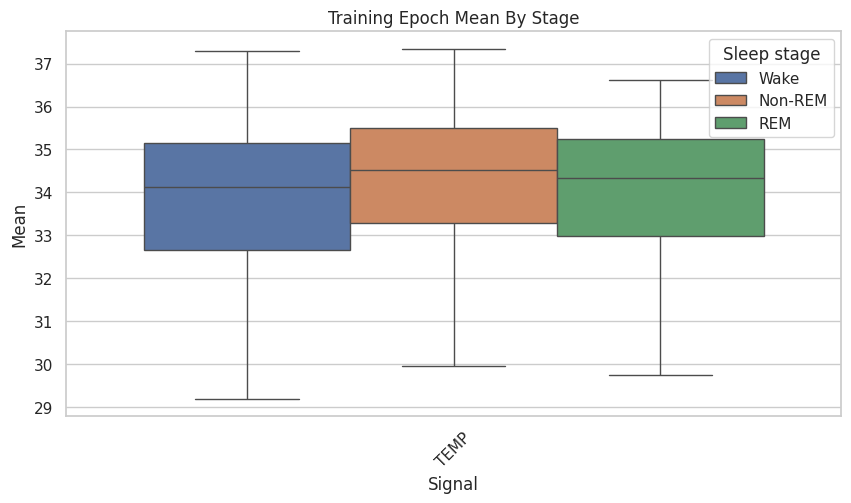

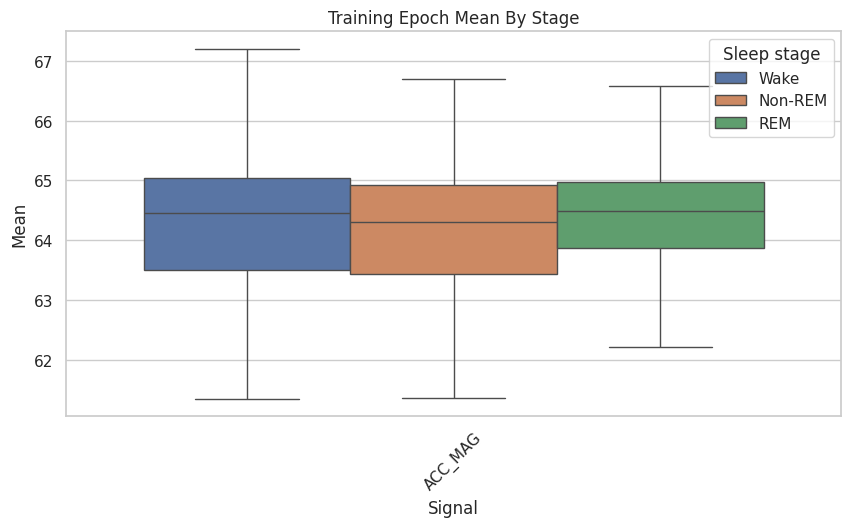

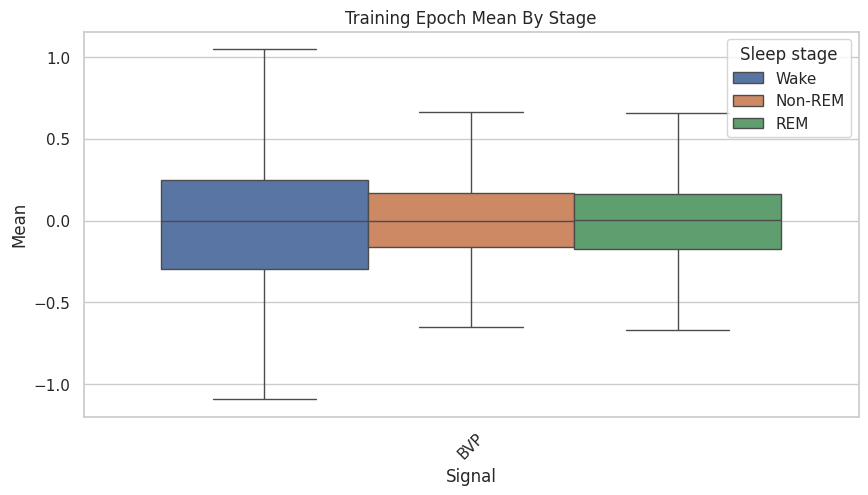

**Interpretation.** These boxplots are descriptive training-set checks, not feature-selection proof. Visible stage separation in HR, IBI, EDA, TEMP, ACC magnitude, or BVP summaries can motivate baseline engineered features, while overlap supports evaluating nonlinear and temporal models.

In [6]:
summary_signals = ["HR", "IBI", "EDA", "TEMP", ACC_MAG_COLUMN, "BVP"]
summary_stat = "mean"

if epoch_signal_summaries.empty:
    signal_summary_long = pd.DataFrame()
    print("Raw signal summaries are unavailable until local raw CSVs are present.")
else:
    value_columns = [
        f"{signal}_{summary_stat}"
        for signal in summary_signals
        if f"{signal}_{summary_stat}" in epoch_signal_summaries.columns
    ]
    signal_summary_long = epoch_signal_summaries.melt(
        id_vars=["participant_id", "epoch_id", "mapped_label"],
        value_vars=value_columns,
        var_name="signal_stat",
        value_name=summary_stat,
    )
    signal_summary_long["signal"] = signal_summary_long["signal_stat"].str.replace(
        f"_{summary_stat}$",
        "",
        regex=True,
    )
    display(signal_summary_long.groupby(["signal", "mapped_label"])[summary_stat].describe())
    for signal in summary_signals:
        signal_df = signal_summary_long[signal_summary_long["signal"] == signal]
        if signal_df.empty:
            continue
        plot_signal_summary_by_stage(
            signal_df,
            value_col=summary_stat,
            save_path=figures_dir / f"stage5_train_{signal.lower()}_mean_by_stage.png",
        )
        plt.show()

    display(
        Markdown(
            "**Interpretation.** These boxplots are descriptive training-set checks, "
            "not feature-selection proof. Visible stage separation in HR, IBI, EDA, TEMP, "
            "ACC magnitude, or BVP summaries can motivate baseline engineered features, "
            "while overlap supports evaluating nonlinear and temporal models."
        )
    )


## Representative Raw Epochs

A small deterministic sample of raw epochs gives qualitative intuition about channel behavior. The cell samples three training participants, selects one valid epoch per available stage for each sampled participant, reloads the corresponding raw rows, derives acceleration magnitude when possible, and plots the requested channels. These examples are not used to tune models or choose participants, and the section reports when valid epochs or raw CSVs are unavailable.

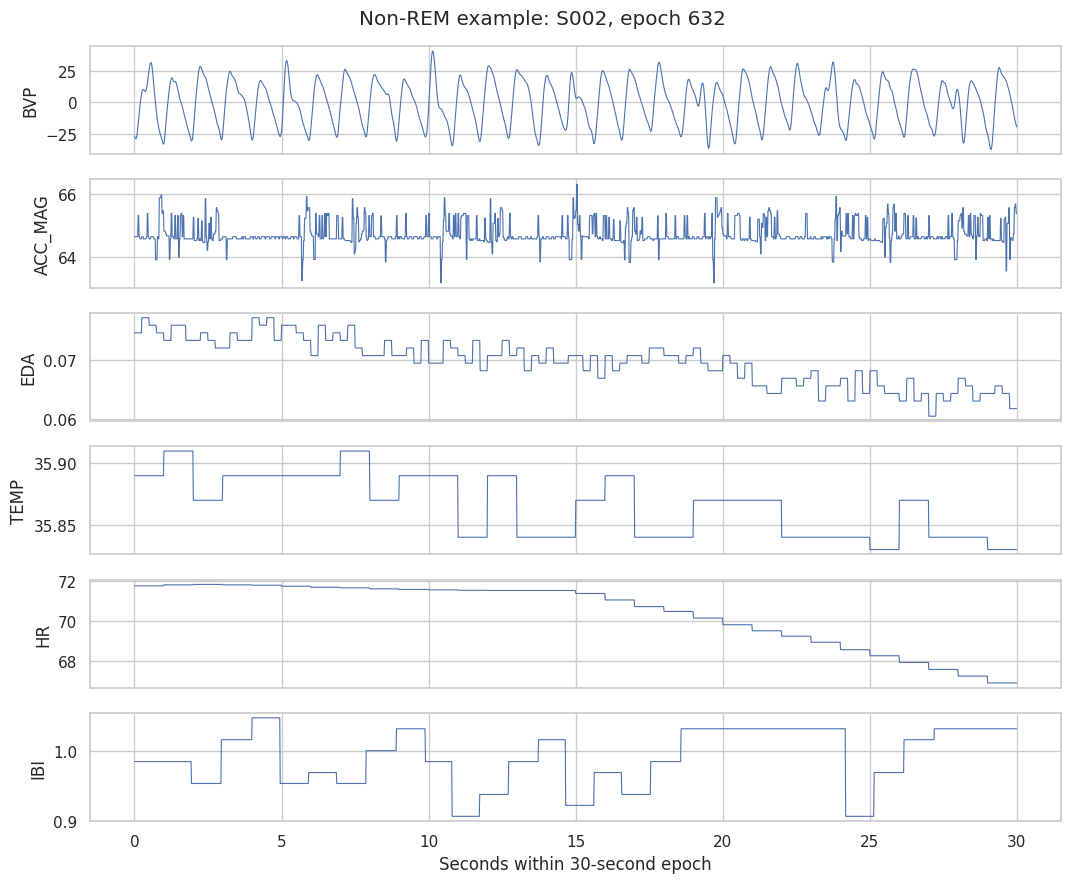

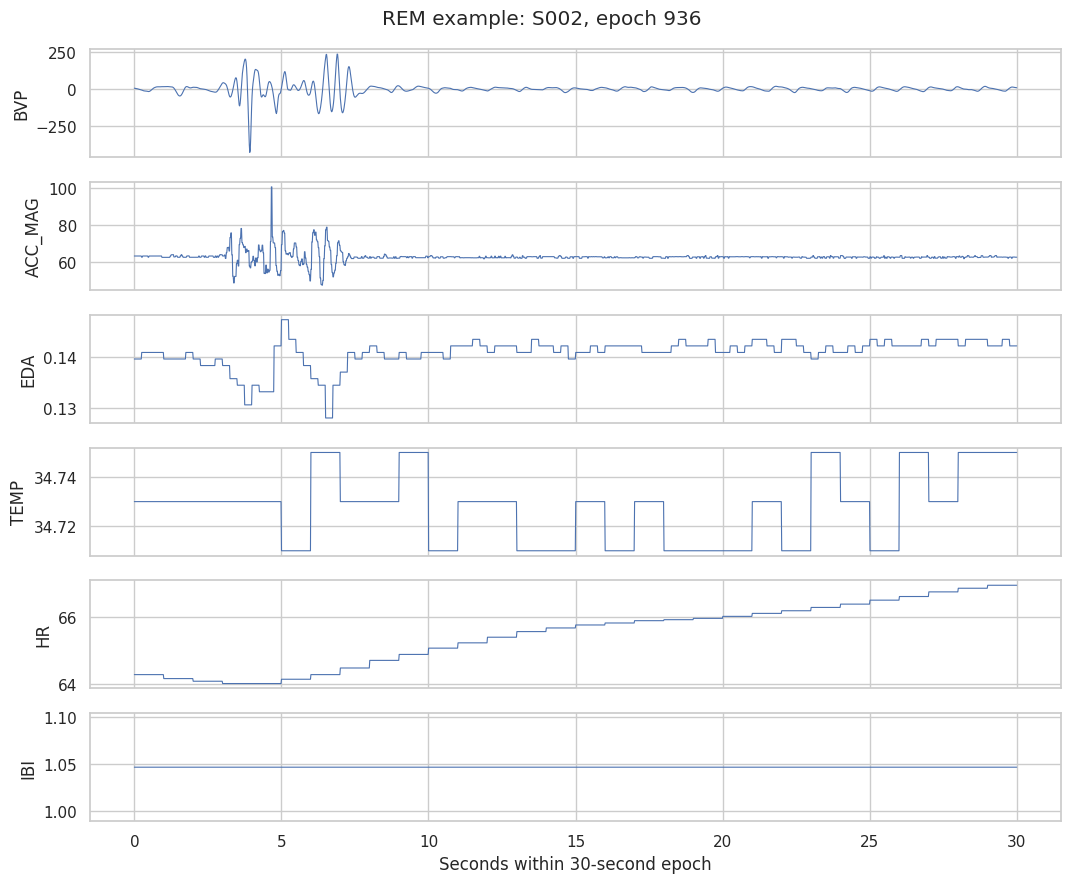

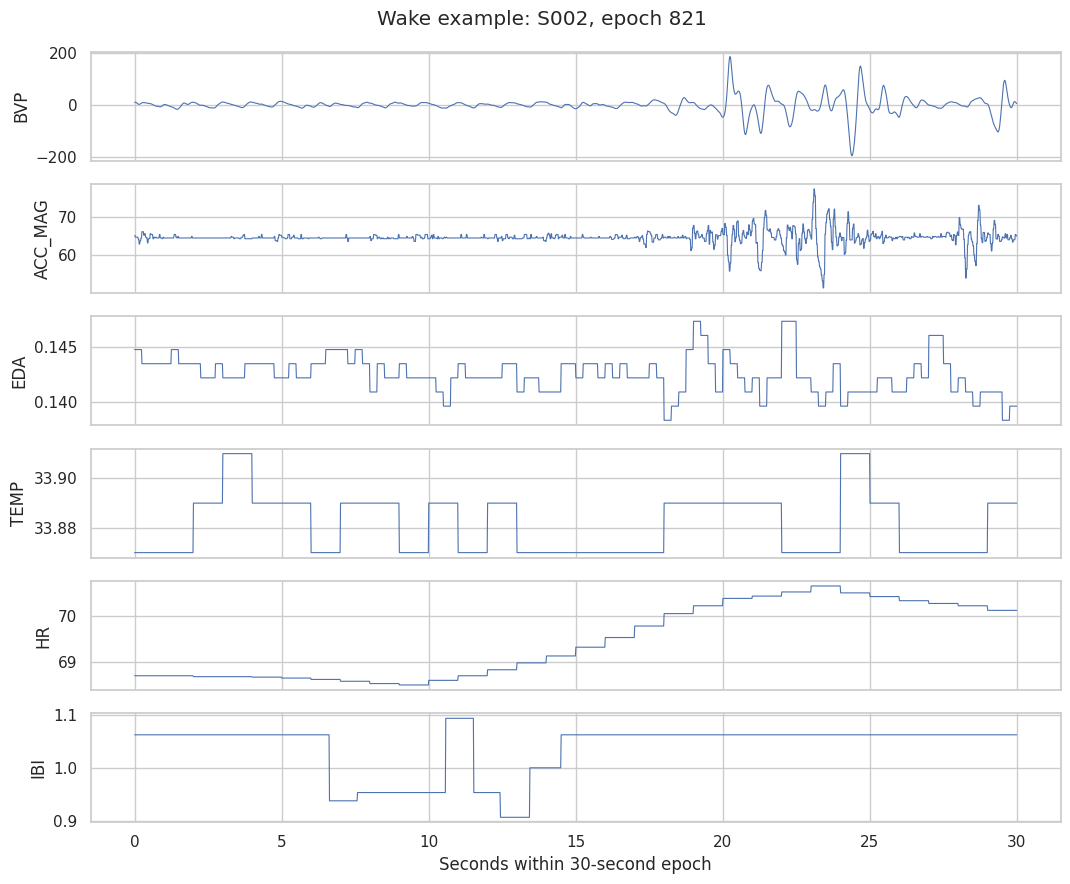

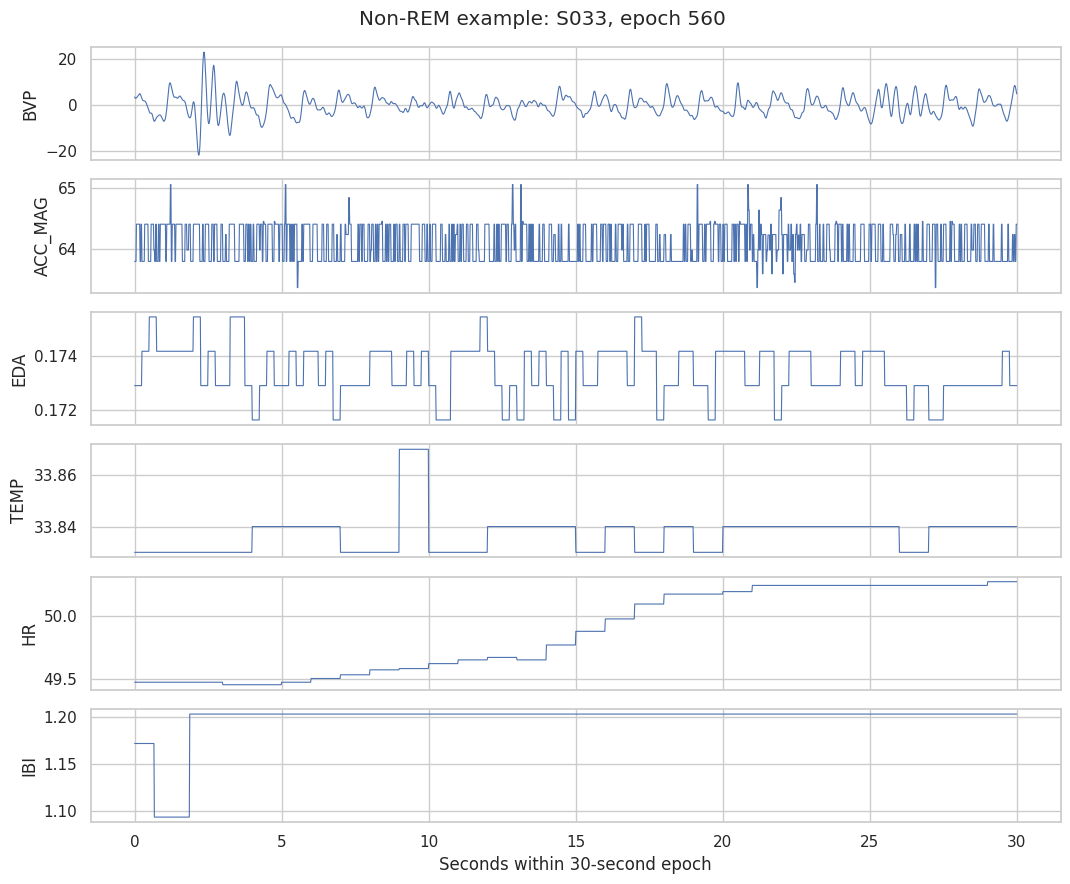

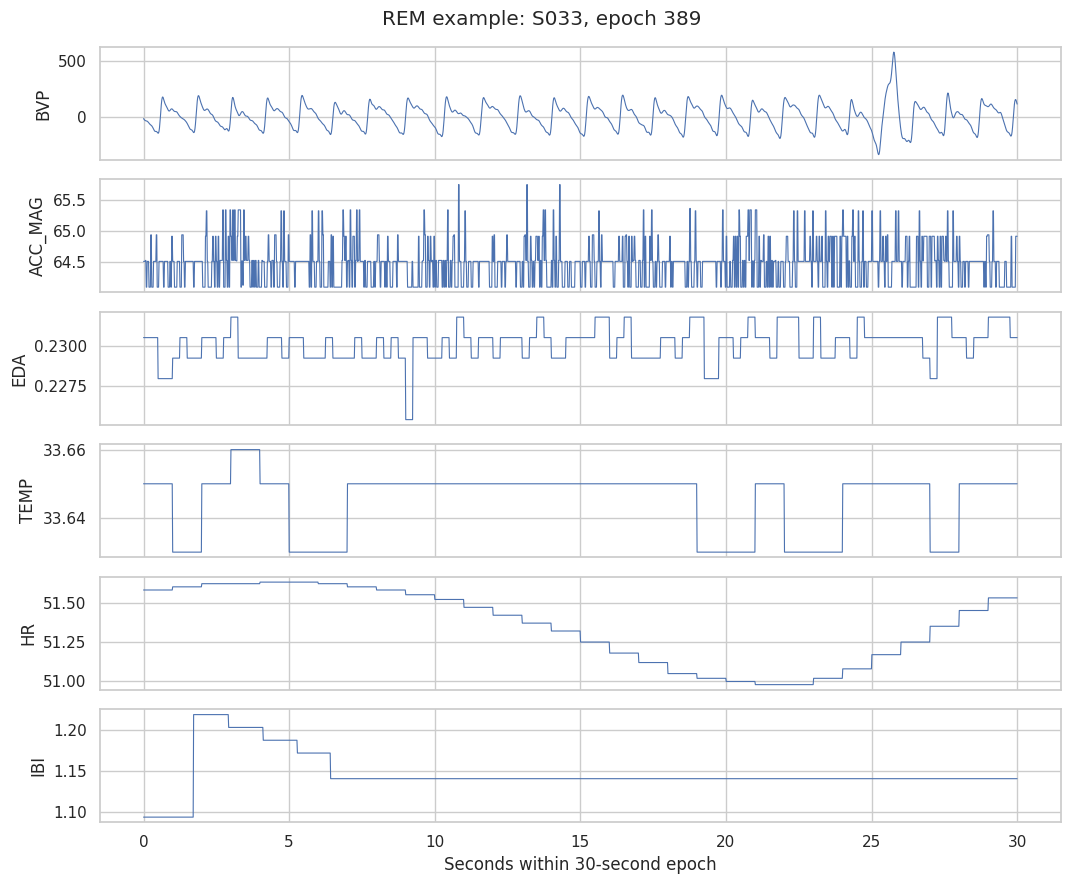

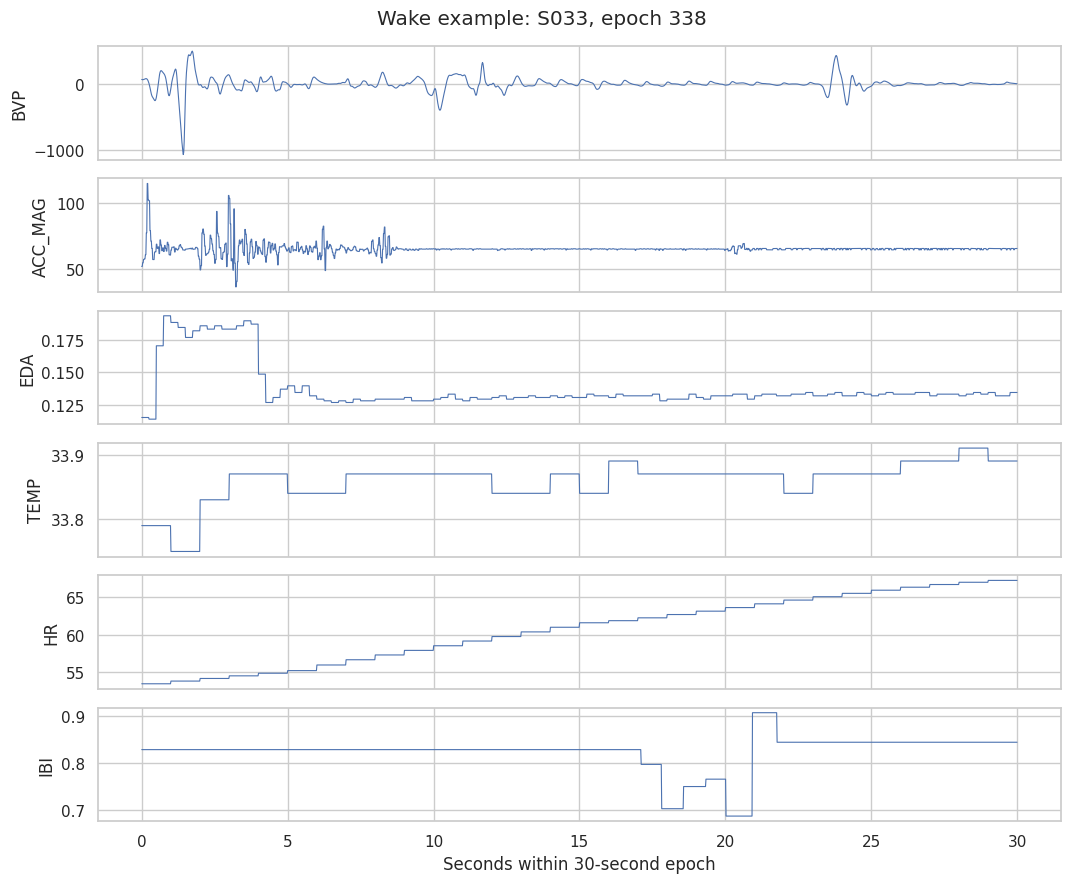

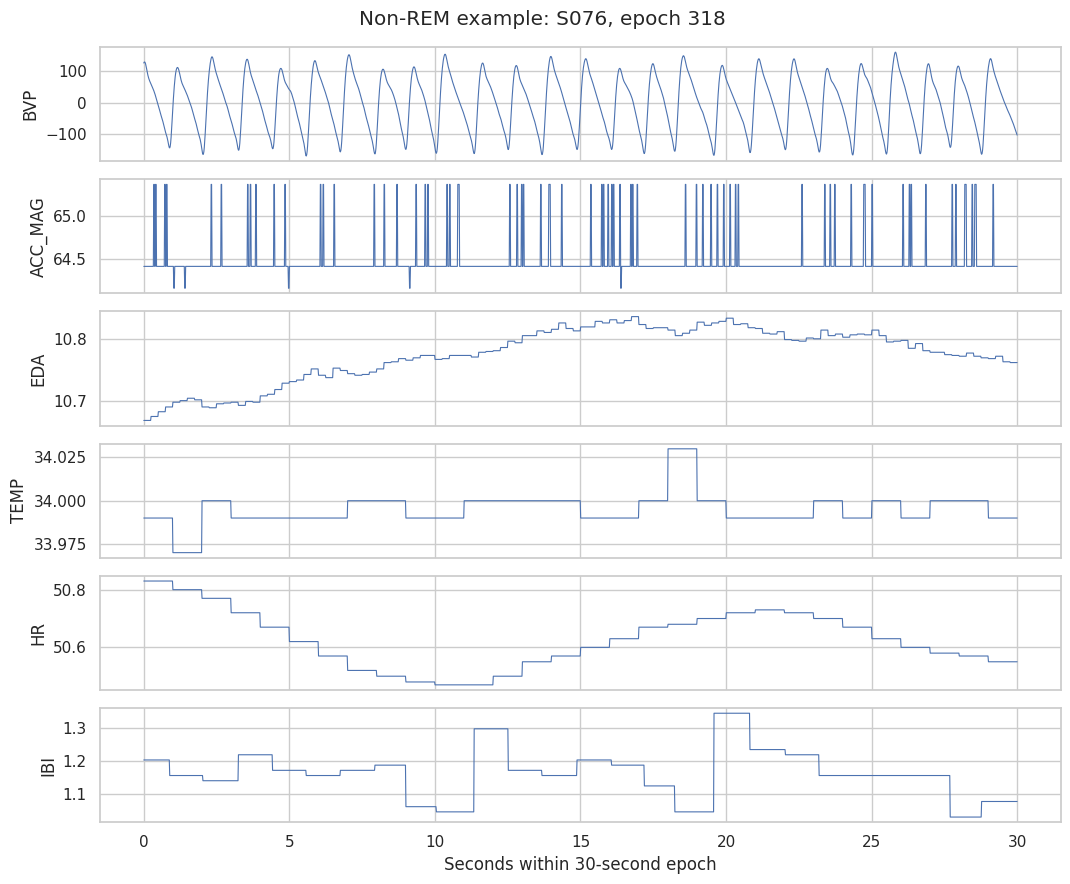

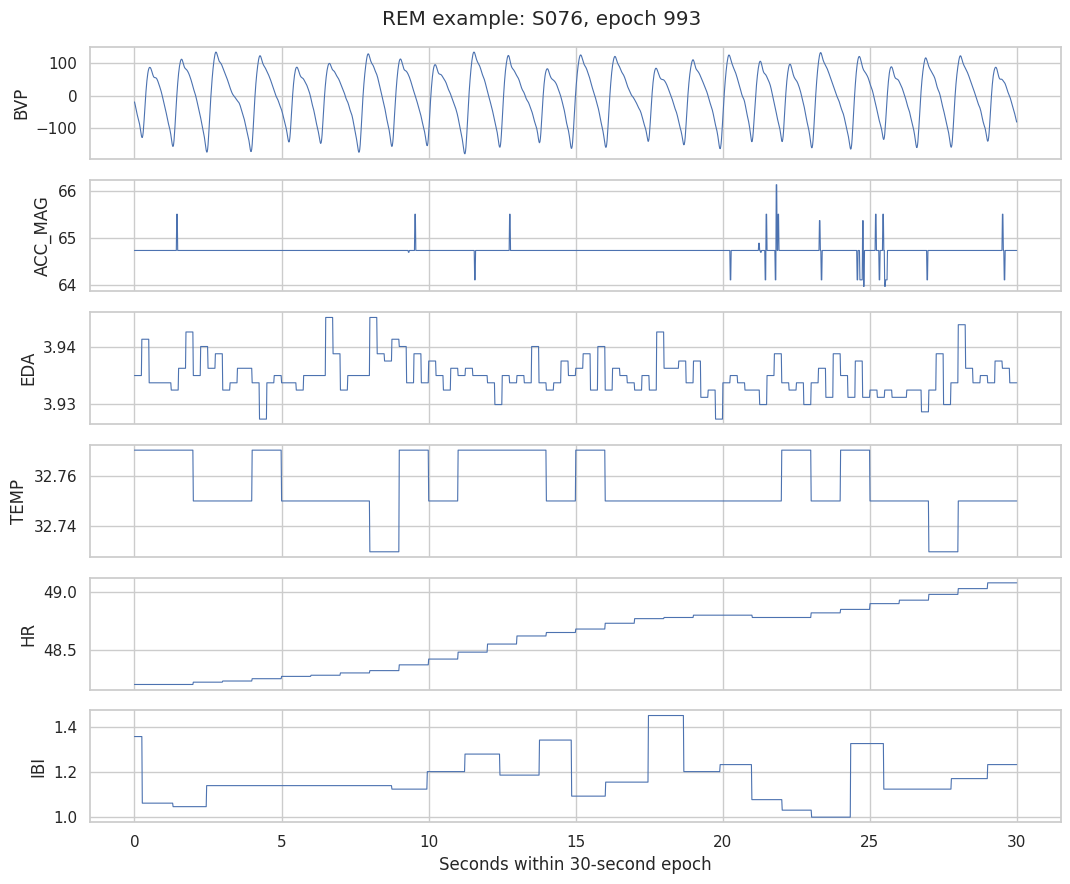

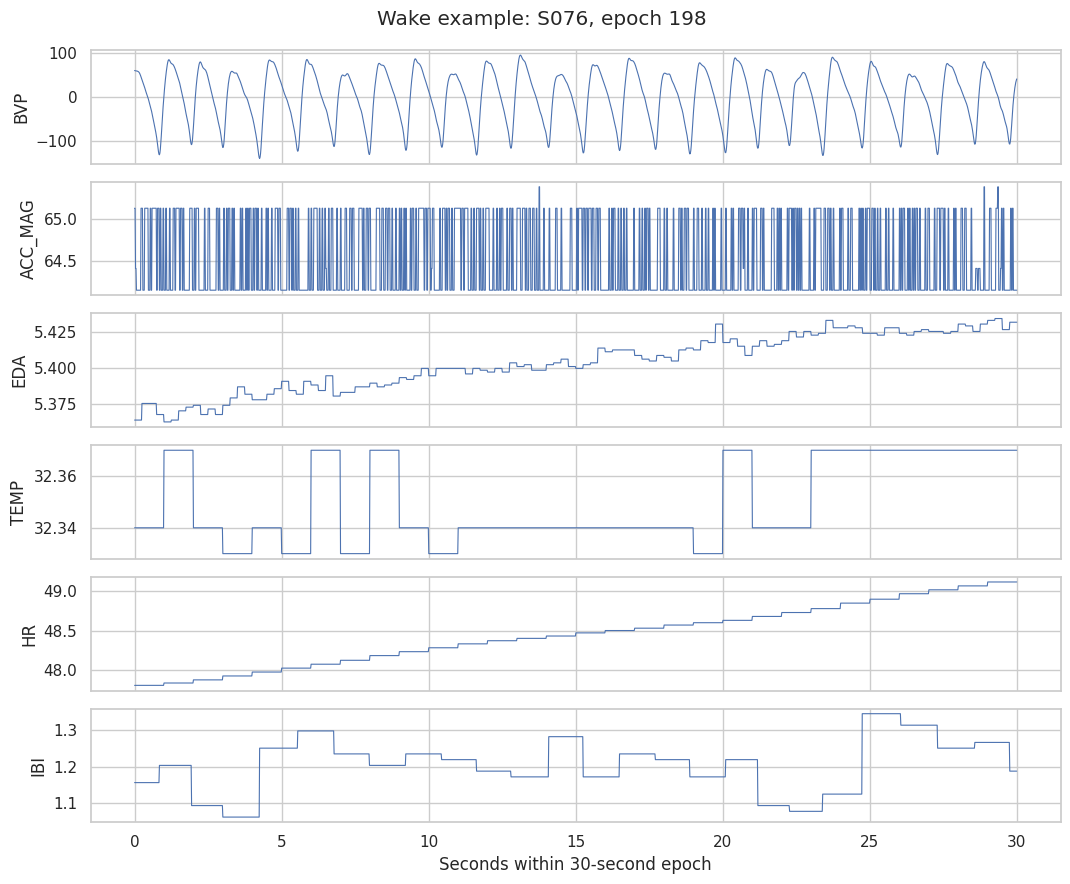

In [7]:
representative_channels = ["BVP", ACC_MAG_COLUMN, "EDA", "TEMP", "HR", "IBI"]

if valid_train_epochs.empty or not raw_data_dir.exists():
    representative_epochs = pd.DataFrame()
    print("Representative raw epoch plots require valid training epochs and local raw CSVs.")
else:
    sampled_participant_ids = (
        valid_train_epochs["participant_id"]
        .drop_duplicates()
        .sample(n=min(3, valid_train_epochs["participant_id"].nunique()), random_state=RANDOM_STATE)
        .sort_values()
    )
    sampled_epochs = []
    for participant_id in sampled_participant_ids:
        participant_epochs = valid_train_epochs[valid_train_epochs["participant_id"] == participant_id]
        for label in TARGET_SLEEP_STAGE_LABELS:
            stage_epochs = participant_epochs[participant_epochs["mapped_label"] == label]
            if stage_epochs.empty:
                continue
            sampled_epochs.append(stage_epochs.sample(n=1, random_state=RANDOM_STATE))
    representative_epochs = pd.concat(sampled_epochs).sort_values(
        ["participant_id", "mapped_label", "epoch_id"]
    )
    for _, epoch_row in representative_epochs.iterrows():
        participant_id = epoch_row["participant_id"]
        raw_path = raw_data_dir / f"{participant_id}_whole_df.csv"
        if not raw_path.exists():
            print(f"Skipping {participant_id}; missing {raw_path}")
            continue
        raw_df = load_participant_csv(raw_path, usecols=EXPECTED_SIGNAL_COLUMNS)
        raw_epoch = raw_df.iloc[int(epoch_row["start_row"]): int(epoch_row["end_row"])]
        if {"ACC_X", "ACC_Y", "ACC_Z"}.issubset(raw_epoch.columns):
            raw_epoch = add_acc_magnitude(raw_epoch)
        title = (
            f"{epoch_row['mapped_label']} example: "
            f"{participant_id}, epoch {int(epoch_row['epoch_id'])}"
        )
        save_path = figures_dir / (
            "stage5_representative_epoch_"
            f"{epoch_row['mapped_label'].replace('-', '_')}_{participant_id}.png"
        )
        fig, axes = plot_raw_epoch_channels(
            raw_epoch,
            representative_channels,
            title=title,
        )
        tick_seconds = [0, 5, 10, 15, 20, 25, 30]
        tick_positions = [
            second * (len(raw_epoch) - 1) / 30 for second in tick_seconds
        ]
        axes[-1].set_xticks(tick_positions)
        axes[-1].set_xticklabels(tick_seconds)
        axes[-1].set_xlabel("Seconds within 30-second epoch")
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        plt.show()


## Temporal Structure

Transitions are computed within each training participant only. The section outputs both transition counts and transition probabilities, then reports the average same-stage probability as a simple temporal-dependence check. The code requires consecutive epoch IDs, so it does not create transitions across participant boundaries or gaps left by excluded epochs.

,Wake,Non-REM,REM
Wake,12975,2096,85
Non-REM,1937,32643,266
REM,205,140,5304


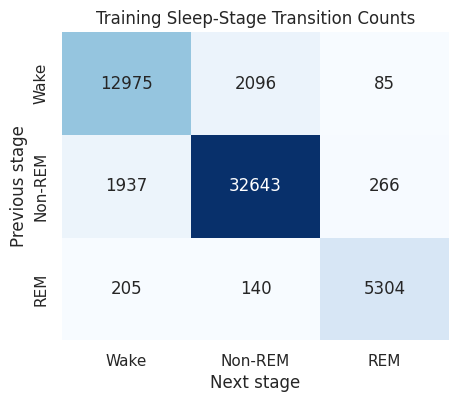

,Wake,Non-REM,REM
Wake,0.856097,0.138295,0.005608
Non-REM,0.055587,0.936779,0.007634
REM,0.036290,0.024783,0.938927


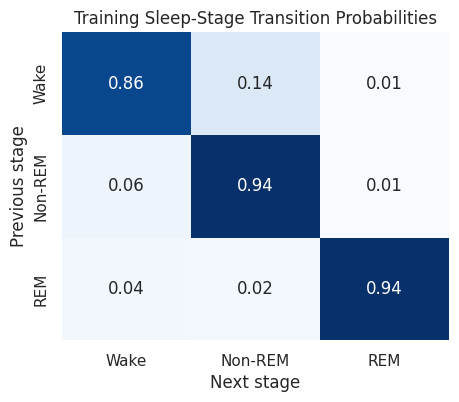

**Interpretation.** The mean same-stage transition probability is 0.91. Strong diagonal probabilities would support models with temporal context, such as a context-window CNN or CNN-GRU.

In [8]:
if valid_train_epochs.empty:
    transition_counts = pd.DataFrame()
    transition_probabilities = pd.DataFrame()
    print("No valid training epochs are available yet.")
else:
    transition_counts, transition_probabilities = transition_matrices(valid_train_epochs)
    display(transition_counts)
    plot_transition_matrix(
        transition_counts,
        title="Training Sleep-Stage Transition Counts",
        fmt="d",
        save_path=figures_dir / "stage5_train_transition_counts.png",
    )
    plt.show()

    display(transition_probabilities)
    plot_transition_matrix(
        transition_probabilities,
        title="Training Sleep-Stage Transition Probabilities",
        fmt=".2f",
        save_path=figures_dir / "stage5_train_transition_probabilities.png",
    )
    plt.show()

    stay_probability = transition_probabilities.values.diagonal().mean()
    display(
        Markdown(
            f"**Interpretation.** The mean same-stage transition probability is "
            f"{stay_probability:.2f}. Strong diagonal probabilities would support "
            "models with temporal context, such as a context-window CNN or CNN-GRU."
        )
    )


## Optional Hypnogram-Like Plots

A few training participants are plotted to show the temporal organization of labels across valid epochs. The cell chooses the training participants with the most valid epochs so the plots are likely to contain enough sequence structure to inspect. These are descriptive training-only plots and should not be used to revise validation or test evaluation.

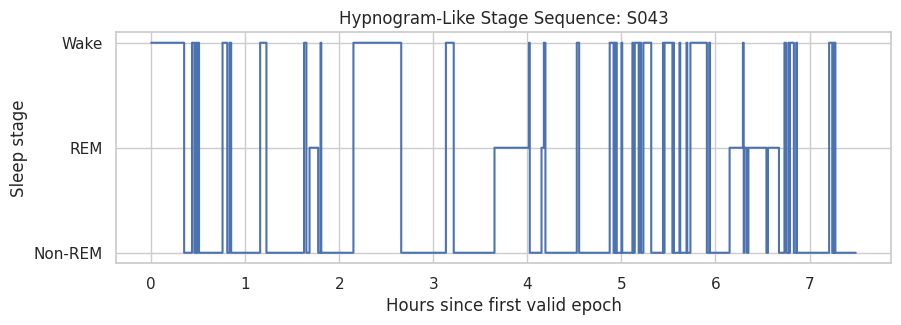

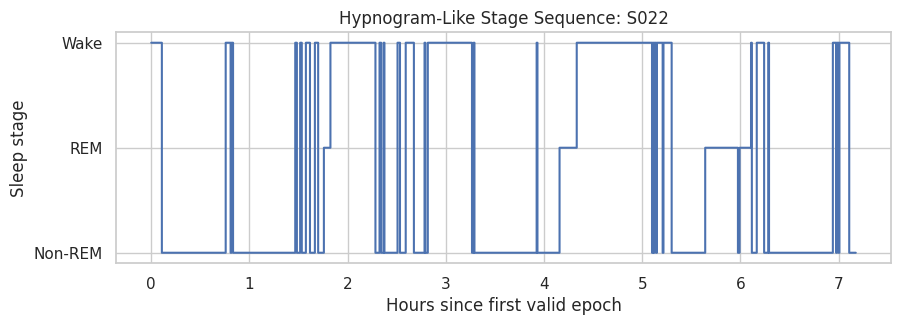

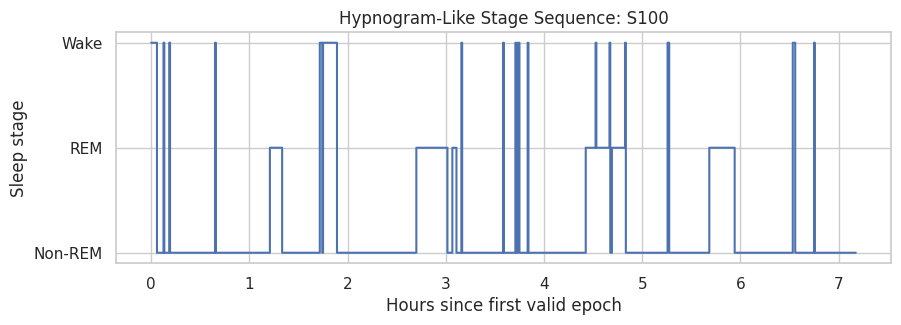

In [9]:
if valid_train_epochs.empty:
    print("No valid training epochs are available yet.")
else:
    hypnogram_participants = (
        valid_train_epochs.groupby("participant_id")
        .size()
        .sort_values(ascending=False)
        .head(3)
        .index
    )
    for participant_id in hypnogram_participants:
        plot_hypnogram(
            valid_train_epochs,
            participant_id=participant_id,
            save_path=figures_dir / f"stage5_hypnogram_{participant_id}.png",
        )
        plt.show()


## Stage 5 Takeaways

Use the executed tables and figures above to answer the Stage 5 questions:

- Is the training data class-imbalanced, and which class is rare?
- Do participant-level class distributions vary enough to affect evaluation?
- Which raw signal summaries show visible training-set differences by sleep stage?
- Do within-participant label transitions show enough temporal dependence to motivate temporal context models?

Downstream preprocessing choices that learn statistics, thresholds, imputers, scalers, feature selectors, or class weights should be fit on the training set only. Validation and test sets should remain untouched until model selection and final evaluation respectively.